как улучшить данные до обработки? мы знаем что поле "зеленое" и занимает большую часть кадра
мы знаем что линии белые. также известно что линии "узкие" и не содержат внутри других цветов: если взять точки 
 поэтому есть смысл рассматривать переходы только между белым и зеленым цветом.



In [1]:
# filed detection
import cv2
from numba.experimental import jitclass
# from imageio.core.imopen import imopen
from numpy.ma.core import shape
import numpy as np

# img = cv2.imread('../tmp/v5_bacground.png', cv2.IMREAD_COLOR)  # road.png is the filename

def init_image_to_process():
    input_video_path = "../materials_part1/2024-11-18 17-53-16.mkv"#"../2024-11-18 17-53-16.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"  #"F:\\Videos\\2024-11-18 17-49-57.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"
    
    cap = cv2.VideoCapture(input_video_path)
    
    from cut_image import get_cut_frame_from_frame
    
    ret, image = cap.read()
    for _ in range(100):
        ret, image = cap.read()
        if not ret:
            pass
        
    image = get_cut_frame_from_frame(image, 2)
    image = cv2.rotate(image, cv2.ROTATE_180)
    img_tmp = cv2.blur(image, (3, 3))
    cv2.imwrite("../tmp/hehe4.png", img_tmp)

# init_image_to_process()



# image = cv2.blur(image, (3, 3))
# image = cv2.blur(image, (3, 3))
# img = cluster_and_recolor(image, 13, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
# print(img)
# img = cluster_and_recolor(img,4)
# cv2.imshow('lanes', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


from sklearn.cluster import KMeans


# flat = img.flatten()
def multiply_list(data):
    tmp = 1
    for i in data:
        tmp *= i
    return tmp


def cluster_and_recolor(img, n_clusters, mode: int = 1, top_n=None, binary=False):
    flat = img.reshape((multiply_list(img.shape) // 3, 3))

    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=3).fit(flat)

    cluster_color_centers = list()
    for i in kmeans.cluster_centers_:
        clr = list()
        for j in i:
            clr.append(int(j))
        cluster_color_centers.append(clr)
    cluster_color_centers = np.array(cluster_color_centers)
    # print(img, "hehe", flat, type(img), "hehe", cluster_color_centers)

    unflat = kmeans.labels_.reshape(img.shape[:-1]).astype(np.uint8)

    if mode == 1:
        return unflat * (255 // n_clusters)
    elif mode == 2 or mode == 3:
        sizes = [0] * len(cluster_color_centers)
        for i in kmeans.labels_:
            sizes[i] += 1
        tmp_sizes = list()
        for num, i in enumerate(sizes):
            tmp_sizes.append((-i, num))
        tmp_sizes = sorted(tmp_sizes)
        remap = [0] * len(sizes)
        for num, i in enumerate(tmp_sizes):
            remap[i[1]] = num
        if mode == 3:
            start_clr = cluster_color_centers[tmp_sizes[0][1]]
            size = tmp_sizes[0][0]
            if top_n is None:
                top_n = 0
            seen = [tmp_sizes[0][1]]
            for i in range(top_n):
                nearest = 0
                dist = np.inf
                size_tmp = 0
                for j in range(n_clusters):
                    if tmp_sizes[j][1] not in seen and np.linalg.norm(
                            start_clr - cluster_color_centers[tmp_sizes[j][1]]) < dist:
                        dist = np.linalg.norm(start_clr - cluster_color_centers[tmp_sizes[j][1]])
                        nearest = tmp_sizes[j][1]
                        size_tmp = tmp_sizes[j][0]
                seen.append(nearest)
                #start_clr = size * (start_clr / (size_tmp + size)) + cluster_color_centers[nearest] * (size_tmp / (size_tmp + size))
                size += size_tmp
            for j in seen:
                remap[j] = seen[0]
        for i in range(len(unflat)):
            for j in range(len(unflat[i])):
                if top_n is None or (mode == 3 and not binary):
                    unflat[i][j] = remap[unflat[i][j]]
                elif binary and mode == 3:
                    if remap[unflat[i][j]] == remap[tmp_sizes[0][1]]:
                        unflat[i][j] = 255
                    else:
                        unflat[i][j] = 0
                elif top_n > remap[unflat[i][j]]:
                    unflat[i][j] = 255
                else:
                    unflat[i][j] = 0
        if top_n is None or mode == 3:
            return unflat * (255 // n_clusters)
        else:
            return unflat
    elif mode == 4:
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                img[i][j] = cluster_color_centers[unflat[i][j]]
        return img


In [2]:
#lines detection
from image_tuner import rgb_tune_test, tune_from_params, rgb_tune_from_params
import numpy as np
import math
import sklearn.cluster as skcl
from numba import jit
from scipy.spatial import ConvexHull
from sklearn.linear_model import LinearRegression

import cv2

# white_color_img = tune_test("../tmp/hehe4.png")  #69 0 153 191 248 255
img_tmp = cv2.imread("../tmp/hehe4.png")
# img_tmp = cv2.imread("/root/Downloads/corridor_field.jpg")
green_color_img = cv2.blur(img_tmp, (3, 3))
green_color_img = cluster_and_recolor(green_color_img, 13, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
white_color_img = tune_from_params(img_tmp, 33, 0, 143, 181, 76, 255)
# rgb_tune_test("/root/Downloads/corridor_field.jpg")
# green_color_img = cluster_and_recolor(green_color_img, 13, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
# white_color_img = tune_from_params(img_tmp, 33, 0, 143, 181, 76, 255)
# green_color_img = tune_from_params(img_tmp,23,113,58,36,255,154)
# white_color_img = rgb_tune_from_params(img_tmp,57,104,117,117,124,137)
# print(white_color_img.shape,len(white_color_img),len(white_color_img[0]))
# cv2.imshow('lanes', white_color_img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# print(img)
@jit
def get_result_edges(white_color_img_i, green_color_img_i):# _i for internal
    # result_edges_i = white_color_img_i * 0
    result_edges_i = np.zeros(white_color_img_i.shape, dtype="uint8")
    for i in range(1, len(white_color_img_i) - 1):
        for j in range(1, len(white_color_img_i[i]) - 1):
            seen_white = 0
            seen_green = 0
            bad = 0
            for k in (-1, 0, 1):
                for t in (-1, 0, 1):
                    if green_color_img_i[i + k][j + t] > 200:
                        seen_green += 1
                    if white_color_img_i[i + k][j + t] > 200:
                        seen_white += 1
                    if green_color_img_i[i + k][j + t] <= 200 and white_color_img_i[i + k][j + t] <= 200:
                        bad += 1
            if seen_white > 1 and seen_green > 2:
                # print("lane")
                result_edges_i[i][j] = 255
    return  result_edges_i
result_edges = get_result_edges(white_color_img,green_color_img)
print("end prep")

analysis = cv2.connectedComponentsWithStats(result_edges,
                                            4,
                                            cv2.CV_32S)
(totalLabels, label_ids, values, centroid) = analysis
areas = list()
for i in values:
    areas.append(i[cv2.CC_STAT_AREA])
areas = sorted(areas, reverse=True)
output = np.zeros(result_edges.shape, dtype="uint8")
for i in range(1, totalLabels):
    area = values[i, cv2.CC_STAT_AREA]

    if area >= areas[30]:
        # Labels stores all the IDs of the components on the each pixel 
        # It has the same dimension as the threshold 
        # So we'll check the component 
        # then convert it to 255 value to mark it white 
        componentMask = (label_ids == i).astype("uint8") * 255

        # Creating the Final output mask 
        output = cv2.bitwise_or(output, componentMask)
    # print (analysis)

# cv2.imshow('lanes', output)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

segments = cv2.HoughLinesP(output, 1, math.pi / 180, 80, 30, 10)
# print(segments.shape,segments)
segments = segments.reshape((len(segments), 2, 2))

# segments[i] = sorted(segments[i])
lines = list()
if False:  #clusterization method   #todo redo segments from vec<int,4> to vec<vec<int,2>,2>
    segm_by_direction_and_sp = list()
    for i_tmp in segments:
        i = i_tmp[0]
        x = i[2] - i[0]
        y = i[3] - i[1]
        if True:
            len_xy = math.sqrt(x * x + y * y)
            x /= len_xy
            y /= len_xy
        if x < 0:
            x *= -1
            y *= -1
        zero = (0, 0)
        if abs(x) > abs(y):
            c1 = i[0] / x
            zero = (0, i[1] - y * c1)
        else:
            c1 = i[1] / y
            zero = (i[0] - x * c1, 0)
        segm_by_direction_and_sp.append((x * 1000, y * 1000, zero[0], zero[1]))
    segm_by_direction_and_sp = np.array(segm_by_direction_and_sp)
    # clusters = skcl.OPTICS(min_samples=4).fit(segm_by_direction_and_sp)
    # clusters = skcl.DBSCAN(min_samples=2).fit(segm_by_direction_and_sp)
    clusters = skcl.HDBSCAN(min_samples=2).fit(segm_by_direction_and_sp)
    # clusters = KMeans(n_clusters=10).fit(segm_by_direction_and_sp)
    centers_of_clusters = dict()
    for i in range(len(segm_by_direction_and_sp)):
        if clusters.labels_[i] not in centers_of_clusters.keys():
            centers_of_clusters[clusters.labels_[i]] = [np.linalg.norm(segments[i][0][:1] - segments[i][0][2:])]
            # print(type(segm_by_direction_and_sp[i].tolist()),,centers_of_clusters[clusters.labels_[i]])
            centers_of_clusters[clusters.labels_[i]].extend(
                (segm_by_direction_and_sp[i] * np.linalg.norm(segments[i][0][:1] - segments[i][0][2:])).tolist())
        else:
            centers_of_clusters[clusters.labels_[i]][0] += np.linalg.norm(segments[i][0][:1] - segments[i][0][2:])
            for j in range(len(segm_by_direction_and_sp[i])):
                centers_of_clusters[clusters.labels_[i]][j + 1] += segm_by_direction_and_sp[i][j] * np.linalg.norm(
                    segments[i][0][:1] - segments[i][0][2:])
    for i in centers_of_clusters.values():
        # print(i)
        # i = [1]
        # i.extend(i_tmp)
        lines.append([[int((i[-2] - 1000 * i[1]) / i[0]), int((i[-1] - 1000 * i[2]) / i[0]),
                       int((i[-2] + 1000 * i[1]) / i[0]), int((i[-1] + 1000 * i[2]) / i[0])]])

#idea: if 2 segments are on line then area on 4 points is minimal


if False:
    for i in range(len(segments)):  #sorted so segms are from x1 to x2 where x1<x2 or x1==x2 and y1<y2
        if segments[i][0][0] < segments[i][1][0]:
            segments[i] = np.array([segments[i][1], segments[i][0]])
        elif segments[i][0][0] == segments[i][1][0] and segments[i][0][1] < segments[i][1][1]:
            segments[i] = np.array([segments[i][1], segments[i][0]])

    st = set()
    for i in segments:
        st.add(tuple(i.reshape((4)).tolist()))
    while True:
        # concatinating segments by using best start and best end points while area metric allows it
        first_best = second_best = None
        best_area = 0
        for i_tmp in st:
            for j_tmp in st:
                i = np.array(i_tmp)
                j = np.array(j_tmp)
                if (i != j).any():
                    area = 0
                    points = np.array([i, j]).reshape((4, 2))
                    for i in range(len(points)):
                        area += np.cross(points[i], points[(i + 1) % len(points)])

                    if first_best is None:
                        first_best = i
                        second_best = j
                        best_area = area
                    else:
                        if best_area > area:
                            best_area = area
                            first_best = i
                            second_best = j
        if area > 500:
            break

        points = np.array([first_best, second_best]).reshape((2, 4))
        line = LinearRegression().fit(points[0], points[1])
        start = (0, line.intercept_)
        direction = (1, line.coef_)


        def project_point(point, start_line, direction_line):
            point -= start_line
            sk = 0
            len_line = 0
            for i in range(len(line)):
                len_line += direction_line[i] ** 2
                sk += direction_line[i] * point[i]
            sk /= len_line
            return start_line + direction_line * sk


        result = (0, 0)
        if first_best[0] < second_best[0]:
            result[0] = first_best[0]
        else:
            result[0] = second_best[0]
        if first_best[0] > second_best[0]:
            result[1] = first_best[1]
        else:
            result[1] = second_best[1]
        result[0] = project_point(result[0], start, direction)
        result[1] = project_point(result[1], start, direction)
        st.remove(first_best)
        st.remove(second_best)
        st.add(np.array(result))
    lines = list(st)

#idea 3: same as idea 2, but using this metric in dbscan
labels = 0
n_clusters = 0
@jit
def cross2d(x, y):
    return np.array([x[..., 0] * y[..., 1] - x[..., 1] * y[..., 0]])

if True:
    @jit
    def custom_distance_v1(a: np.array, b: np.array):  # works iff a and b goes into different directions
        a = a.reshape((2, 2))
        b = b.reshape((2, 2))
        points = [a[0], a[1], b[0], b[1]]
        sum = cross2d(points[-1], points[0])
        for i in range(1, len(points)):
            sum += cross2d(points[i - 1], points[i])
        return np.linalg.norm(sum)  #eps = 10

    @jit
    def custom_distance_v2(a: np.array, b: np.array):
        a = a.reshape((2, 2))
        b = b.reshape((2, 2))
        points = [a[0], a[1], b[0], b[1]]
        sum = cross2d(points[-1], points[0])
        for i in range(1, len(points)):
            sum += cross2d(points[i - 1], points[i])
        points[0], points[1] = points[1], points[0]
        sum2 = cross2d(points[-1], points[0])
        for i in range(1, len(points)):
            sum2 += cross2d(points[i - 1], points[i])
        return max(np.linalg.norm(sum), np.linalg.norm(sum2))  #eps = 100

    @jit
    def custom_distance_v3(a: np.array, b: np.array):
        a = a.reshape((2, 2))
        b = b.reshape((2, 2))
        points = [a[0], a[1], b[0], b[1]]
        sum = cross2d(points[-1], points[0])
        for i in range(1, len(points)):
            sum += cross2d(points[i - 1], points[i])
        points[0], points[1] = points[1], points[0]
        sum2 = cross2d(points[-1], points[0])
        for i in range(1, len(points)):
            sum2 += cross2d(points[i - 1], points[i])
        return max(np.linalg.norm(sum), np.linalg.norm(sum2)) / (
                    np.linalg.norm(a[0] - a[1]) + np.linalg.norm(b[0] - b[1]))  #eps = 5


    # print(segments)
    clustering = skcl.DBSCAN(eps=5, min_samples=1, metric=custom_distance_v3).fit(
        segments.reshape((segments.shape[0], 4)))
    labels = clustering.labels_
    n_clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)
    # print("labels,cluster_n ",labels,n_clusters)


def add_up_segments_v1(data: np.array):
    data = data.astype(np.float64)

    #prepare
    # def is_same_direction(a,b):
    #     v1 = np.cross(b-a[0],a[1]-a[0])/np.linalg.norm(a[1]-a[0])*(a[1]-a[0]).reshape((1,2))
    #     delta = np.linalg.norm((a[1]-a[0])-(v1[1]-v1[0]))
    #     return delta<1e-5
    # def is_same_direction_v2(a,b):
    #     v1 = np.cross(b-a[0],a[1]-a[0])/np.linalg.norm(a[1]-a[0])
    #     delta = 1-(v1[1]-v1[0])
    #     return delta<1e-5
    def is_same_direction_v3(a, b):
        return np.dot(a[1] - a[0], b[1] - b[0]) > 0

    # print(is_same_direction_v3(np.array([[1,2],[3,4]]),np.array([[9,10],[7,8]])))#false
    # print(is_same_direction_v3(np.array([[1,2],[3,4]]),np.array([[5,6],[7,8]])))#true
    for i in range(1, len(data)):
        if not is_same_direction_v3(data[0], data[i]):
            data[i][0], data[i][1] = data[i][1], data[i][0]
    sum_weight = np.linalg.norm(data[0][1] - data[0][0])
    sum_direction = data[0][1] - data[0][0]
    avg_point = (data[0][0] + data[0][1]) * sum_weight
    for i in range(1, len(data)):
        tmp_w = np.linalg.norm(data[i][1] - data[i][0])
        sum_direction += data[i][1] - data[i][0]
        avg_point += (data[i][0] + data[i][1]) * tmp_w
        sum_weight += tmp_w
    sum_direction /= sum_weight
    avg_point /= sum_weight * 2
    start = 0
    end = 0
    for i in range(len(data)):
        start = min(start, np.dot(sum_direction, data[i][0] - avg_point))
        end = max(end, np.dot(sum_direction, data[i][1] - avg_point))
    return (np.array([start * sum_direction, end * sum_direction]) + avg_point).astype(np.int32)


grouped = dict()
for i in range(len(segments)):
    if labels[i] not in grouped.keys():
        grouped[labels[i]] = [segments[i]]
    else:
        grouped[labels[i]].append(segments[i])
if True:
    new_segments = list()
    for i in grouped.values():
        new_segments.append(add_up_segments_v1(np.array(i)))
    segments = new_segments


end prep


In [3]:
def homography_matrix(segs):
    def homography_matrix_by_4_vec(vecs):  # vecs = [a,b,c,d],  a,b -> (1,0) c,d ->(0,1)
        for i in range(len(vecs)):
            vecs[i] = np.append(vecs[i], 1)
        # notice that a-b = alpha is eigenvector with value 0 as well as c-d = beta
        # than:
        # A = V*L*V^(-1)
        # L = [[0,0,0],[0,0,0],[0,0,x]]
        # and V = [alpha,beta,alpha cross beta]
        alpha = vecs[0] - vecs[1]
        beta = vecs[2] - vecs[3]
        gamma = np.cross(alpha, beta)

    # idea v2: try all matricies and choose one which maximizes metric.
    # for all  segments generate vectors length of 1
    # for all pairs of this vectors find matrix that minimizes some function
    vectors = list()
    for i in segs:
        point = (i[0] - i[1]) / np.linalg.norm(i[0] - i[1])
        vectors.append(point)
    vectors_v2 = np.array(vectors).reshape((len(vectors), 1, 2))
    # def get_metric(vecs,)
    best_val = -1e9
    best_m = np.identity(3)
    for i in range(len(vectors)):
        for j in range(len(vectors)):
            if i != j:
                for k in range(len(vectors)):
                    if i != k and j != k:
                        for f in range(len(vectors)):
                            if f != k and f != j and f != k:
                                mat, mask = cv2.findHomography(
                                    np.array([vectors[f], vectors[i], vectors[j], vectors[k]]),
                                    np.array([[0, 100], [100, 0], [100, 0], [0, 100]]))
                                # print(vectors.shape,mat.shape)
                                vecs = cv2.perspectiveTransform(vectors_v2, mat).reshape((len(vectors), 2))
                                groups_size = [0, 0, 0]  # hor,vert,bad
                                for t in vecs:
                                    t_p = t / np.linalg.norm(t)
                                    if np.abs(np.abs(np.dot(t_p, np.array([1, 0]))) - 1) < 1 / 8:
                                        groups_size[0] += 1
                                    elif np.abs(np.abs(np.dot(t_p, np.array([0, 1]))) - 1) < 1 / 8:
                                        groups_size[1] += 1
                                    else:
                                        groups_size[2] += 1
                                val = groups_size[0] * groups_size[1] - groups_size[2]
                                # print(groups_size)
                                if val > best_val:
                                    print(groups_size)
                                    # print()
                                    best_val = val
                                    best_m = mat

    print(best_val, best_m)

    return best_m



# homograpy matrix, for transfromation that minimizes sum of distances between each end of segments and line that goes trough center of segment and "horizontal" or "vertical" point at the horizon, where this points represents points to which are all parallel horizontal/vertical lines are converging
def homography_matrix_v2(hor_point1,hor_point2,center_pos,only_points = False):#,fov_px,fov_angle):
    #hereinafter assuming center of image is (0,0), i.e. (0,0) is point through perpendicular from "focal point" is goes
    #todo:convert edges to p1 and p2 solution: watch in deepseek, has intersting way of searching with ransak. also points p1 and p2 are called vanishing points and there are some papers in internet about them.
    def find_distance_fp_to_plane_v1(fov_pixels,
                                     field_of_view):  #hor[0]*x+hor[1]*y = hor[2] ; field_of_view in degrees - angle at which edges of image displayed, fov_pixels is number of pixels corresponding to fov
        return fov_pixels / (2 * math.tan(field_of_view / 2))

    # do not work if horizontal lines are parallel to horizon.
    #assuming that perpendicular line from "focal point" (point from which rays are shoot in point-and-plane approximation of camera) onto "focal plane" (plane of image in approximation ...) goes through center of image
    def find_distance_fp_to_plane_v2(p1, p2, p3,
                                     angle=math.pi / 2) -> float:  #p1 is horizont point for vertical lines,p2 is horizont point for horizontal lines, p3 is nearest point on horizon to center of image. returns distance in pixels
        #let's derive formula:
        # look on triangle FP, p1,p2:
        # let segment p1-p3 called a, p3-p2 called b, angle fp-p1-p2 is beta, angle p2-fp-p1 is alpha, segment fp-p3 is h
        # angle fp-p3-p1 is 90 deg based on assumption
        # then tg(beta) = h/a, tg(180-alpha-beta) = -tg(alpha + beta) = h/b
        #then -tg(beta)/tg(alpha+beta) = b/a
        #then -tg(beta)/((tg(alpha)+tg(beta))/(tg(1-tg(alpha)tg(beta))) = b/a
        #then tg(beta) = x, tg(alpha) = c
        # (-x+c*x**2)/(x+c) = b/a
        #then -x+c*x**2 -x*b/a-c*b/a = 0
        # same as: c*x**2 +(-1-b/a)*x-c*b/a = 0
        # d = 1+2*b/a+(b/a)**2+4*c**2*b/a
        # x = ...: x is positive
        a = np.linalg.norm(p1 - p3)
        b = np.linalg.norm(p2 - p3)
        c_p = math.tan(
            math.pi / 2 - angle)  # c_p = ctg(angle) = tg(90-angle) = 1/tg(angle) needed because tg(90) -> inf
        # d = 1+2*b/a+(b/a)**2+4*b/a*c*c
        # x = ((1+b/a)+math.sqrt(d))/(2*c)
        h = 0
        if angle != math.pi/2:
            x = ((1 + b / a) * c_p + math.sqrt((1 + 2 * b / a + (b / a) ** 2) * c_p ** 2 + 4 * b / a)) / 2
            h = x * a
        else:
            h = math.sqrt(a*b)#len of perpendicular to hypotenuse is sqrt of multiplication of projections of sides onto hypotenuse
            
        print("h and p3" ,h,(np.linalg.norm(p3)),(p3))
        ans = math.sqrt(h**2-np.linalg.norm(p3)**2)#h is distance from p3 to focal point, because this line is not necessary perpendicular to focal plane and line that goes through center is, this step is needd
        return ans

    def calculate_p3(p1, p2):
        return np.dot(p1,p1-p2)/np.linalg.norm(p1-p2)**2*(p2-p1)+p1 # simplification of following
    
    
        # a = np.linalg.norm(p1)
        # b = np.linalg.norm(p2)
        # c = np.linalg.norm(p1-p2)

        a_p = np.dot(p1, p2 - p1)  #same in case of relation as: np.dot(-p1,p2-p1)/c# same as: (np.dot(-p1,p2-p1)/a/c)*a
        b_p = np.dot(p2, p1 - p2)  #same in case of relation as: np.dot(-p2,p1-p2)/c# same as: (np.dot(-p2,p1-p2)/b/c)*b
        return a_p / (a_p + b_p) * p1 + b_p / (a_p + b_p) * p2

    def angle_of_camera_v1(distance_to_fp, p3):
        """
        :return: angle between camera axis and horisontal line (if camera look at the horison, angle is 0)
        """
        return math.atan(np.linalg.norm(p3) / distance_to_fp)

    def homography_matrix_internal(p1, angle, scale, p3, distance_to_fp):
        """
        assuming camera axis lower than horizon :todo fix this
        :param p1:  is horizont point for vertical lines
        :param angle: angle of tilt perpendicular to horizon
        :param scale: relation of real field(in pixels) to pixels on image
        :param p3: p3
        :param distance_to_fp: one extensive parameter, distance to focal point
        :return: homography matrix
        """
        hdir = np.array([-p3[1], p3[0]])
        hdir /= np.linalg.norm(hdir)
        hp1 = hdir * 1000
        hp2 = -hdir * 1000
        hpr1 = hp1 * scale
        hpr2 = hp2 * scale
        #we dont want to accidentaly put one of point on horizon so we halfing angle between p3 and camera axis
        hp3 = p3 * math.tan(angle/2)/math.tan(angle)
        p3_normed = p3/np.linalg.norm(p3)
        hpr3 = distance_to_fp * scale * p3_normed# because of new_angle * 2 = angle, which creates isosceles triangle
        hp4 = - distance_to_fp / math.tan(angle) * p3_normed
        hpr4 = -p3_normed * math.cos(angle) * scale * distance_to_fp
        #decomposition onto orthogonal basis
        p1_for_scale = p1/2
        p1_p_hdir = np.dot(hdir, p1_for_scale) * hdir
        p1_p_p3 = p1 - p1_p_hdir
        #projection of basis
        vert_angle = np.arctan(np.linalg.norm(p1_p_p3)/distance_to_fp)
        p1_p_p3r = p1_p_p3*math.cos(vert_angle)/math.sin(angle-vert_angle)*scale  # some geometry
        p1_p_hdirr = p1_p_hdir * scale * math.sin(angle) *math.cos(vert_angle)/ math.sin(
            angle - vert_angle)
        p1r =  p1_p_p3r+p1_p_hdirr #  decompose vector into hp3 and hdir, project hdir with scale2(where scale2 computed from sinus theorem and scale), and hp3 with scale of (smth)
        
        cos_rot = np.dot(p1r,np.array((1,0)))/np.linalg.norm(p1r)
        sin_rot = math.sqrt(1-cos_rot**2)
        rot_mat = np.array([[cos_rot,sin_rot],[-sin_rot,cos_rot]])# todo maybe wrong direction
        
        print(np.array([hp1,hp2,hp3,hp4])+center_pos,np.array([hpr1,hpr2,hpr3,hpr4])+center_pos,rot_mat,angle)
        hpr1 = rot_mat.dot(hpr1)
        hpr2 = rot_mat.dot(hpr2)
        hpr3 = rot_mat.dot(hpr3)
        hpr4 = rot_mat.dot(hpr4)
        if only_points:
            return np.array([hp1,hp2,hp3,hp4])+center_pos,np.array([hpr1,hpr2,hpr3,hpr4])+center_pos
        
        return cv2.findHomography(np.array([hp1,hp2,hp3,hp4])+center_pos,np.array([hpr1,hpr2,hpr3,hpr4])+center_pos)
        # return cv2.findHomography(np.array([hpr1,hpr2,hpr3,hpr4]),np.array([hp1,hp2,hp3,hp4])+400)
        # return cv2.getPerspectiveTransform(np.array([hp1,hp2,hp3,hp4]),np.array([hpr1,hpr2,hpr3,hpr4]))
    if True:
        hor_point1 = np.copy(hor_point1)
        hor_point2 = np.copy(hor_point2)
        hor_point1-=center_pos
        hor_point2-=center_pos
        print("hor points: ",hor_point1,hor_point2)
        p3 = calculate_p3(hor_point1,hor_point2)
        distance = find_distance_fp_to_plane_v2(hor_point1,hor_point2,p3,angle=math.pi/180*87)
        angle = angle_of_camera_v1(distance,p3)
        assert(abs(angle)>1e-5)
        print(distance,angle)
        return homography_matrix_internal(hor_point1,angle,0.4,p3,distance)
# matrix = homography_matrix(segments)        

# print(white_color_img)

if False:
    # homography_matrix_v2(np.array([10.,0.]),np.array([-10.,0.]),(100,100))
    for i in range(1,5):
        center = np.array([100,100])
        offset = np.array([0,10])
        homography_matrix_v2(np.array([10.*i,0.])+center+offset,np.array([-10.*i,0.])+center+offset,center)
    # print("-"*200)
    # for i in range(1,5):#ok
    #     center = np.array([100,100])*i
    #     offset = np.array([0,10])
    #     homography_matrix_v2(np.array([10.,0.])+offset+center,np.array([-10.,0.])+offset+center,center)
    # print("-"*200)   #ok,same as previous
    # for i in range(1,5):
    #     center = np.array([100,100])*i
    #     offset = np.array([0,10])
    #     homography_matrix_v2(np.array([-10.,0.])+offset+center,np.array([10.,0.])+offset+center,center)
    # print("-"*200)   #ok, same as previous
    # for i in range(1,5):
    #     center = np.array([100,100])*i
    #     offset = np.array([10,0])
    #     homography_matrix_v2(np.array([0.,10.])+offset+center,np.array([0.,-10.])+offset+center,center)
    print("-"*200)#this test is failing because my code now works as it should and it cannot process perfectly horizontal camera position
    for i in range(1,5):
        center = np.array([100,100])
        offset = np.array([0,0])
        homography_matrix_v2(np.array([10.*i,0.])+center+offset,np.array([-10.*i,0.])+center+offset,center)
    print("-"*200)
    for i in range(-3,3):
        center = np.array([100,100])
        offset = np.array([0,10])*i
        homography_matrix_v2(np.array([100.,0.])+offset+center,np.array([-100.,0.])+offset+center,center)
    # print("-"*200)
    # for i in range(1,5): #ok
    #     center = np.array([100,100])*i
    #     offset = np.array([0,10])
    #     homography_matrix_v2(np.array([-10.,0.])+offset+center,np.array([10.,0.])+offset+center,center)
    # print("-"*200)
    # for i in range(1,5): #ok
    #     center = np.array([100,100])*i
    #     offset = np.array([0,-10])
    #     homography_matrix_v2(np.array([-10.,0.])+offset+center,np.array([10.,0.])+offset+center,center)

In [4]:

# output_2 = cv2.warpPerspective(img_tmp,matrix,(3000,3000))
output_2 = output
print(output_2.shape)
# segments = cv2.perspectiveTransform(np.array(segments).reshape((len(segments)*2,1,2)).astype(np.float32),matrix).reshape((len(segments),2,2)).astype(int)+np.array((500,500))
# print(segments)
# print(lines)
output_2 //= 5
for i in range(len(segments)):
    output_2 = cv2.line(output_2, segments[i][0], segments[i][1], 255)  # 40 kmeans is good

# cv2.imshow('lanes', output_2)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

(537, 714)


In [5]:
from bisect import bisect_left
class line:
    def __init__(self ,center= np.array([0,0]),direction= np.array([1,0]),calc_rot:int = 1,internal_id = -1):
        self.center = center
        self.direction  = direction/np.linalg.norm(direction)
        #self.space = np.ndarray([0,1])# space is orthogonal to direction. if sign(proj(space,vec))*sign(proj(direction,vec)) is positive, than vec in target cone, if negative - othervise
        self.calc_rot = calc_rot#1 or -1, if 1, then if rotating clockwise tangent to rotation will be going to center, -1 otherwise
        self.points = list()
        self.other_lines_ids = list()
        self.internal_id = internal_id
    
    def add_point(self,point,line_id):
        self.points.append([np.dot(self.direction,point-self.center),line_id])
    
    def sort_points(self):
        self.points = sorted(self.points)
        for i in range(len(self.points)):
            self.other_lines_ids.append(self.points[i][1])
            self.points[i] = self.points[i][0]
    
    def get_other_line(self,id):
        return self.other_lines_ids[id]
    
    def get_point_id(self,point):
        proj = np.dot(self.direction,point-self.center)
        near_id = bisect_left(self.points,proj)
        if near_id>=len(self.points):
            # print("wrong guess", proj-self.points[-1])
            near_id = len(self.points)-1
        now= np.linalg.norm(proj-self.points[near_id])
        other1 = other2 = now*2
        if near_id<len(self.points)-1:
            other1 = np.linalg.norm(proj-self.points[near_id+1])
        if near_id>0:
            other2 = np.linalg.norm(proj-self.points[near_id-1])
        if other1<now:
             near_id+=1
        elif other2<now:
             near_id-=1
        # print(now,other1,other2)
        # print("distance ", np.linalg.norm(point-self.get_point(near_id)))
        # for i in range(-1,len(self.points)+1):
        #     print("to other",np.linalg.norm(point-self.get_point(i)))
        return near_id
            
    
    def next_point(self,point):
        pos = self.get_point_id(point)+1
        if pos == len(self.points):
            return None
        return self.get_point(pos)
    
    def prev_point(self,point):
        pos = self.get_point_id(point)-1
        if pos == -1:
            return None
        return self.get_point(pos)
    
    def next_point_rot(self,point_id,prev):
        ans = self.get_point(point_id-1)
        current = self.get_point(point_id)
        if cross2d(current-prev,ans-current)>0:
            return point_id-1
        elif cross2d(current-prev,self.get_point(point_id+1)-current)>0:
            return point_id+1
        raise Exception("no appropriate direction found")
    
    def should_add(self,from_point_id,to_point_id):

        val = np.sign(np.dot(self.get_point(to_point_id)-self.get_point(from_point_id),self.center-(self.get_point(to_point_id)+self.get_point(from_point_id))/2))*self.calc_rot
        # print(val)
        return val<0
        #return cross2d(self.get_point(to_point_id)-self.get_point(from_point_id),self.direction)>0

    def should_add_point(self,point):# as if this point was previous point in hull
        proj_point = np.dot(point-self.center,self.direction)*self.direction+self.center
        other = np.dot(point-self.center,self.direction)/2*self.direction+self.center
        if cross2d(proj_point-point,other-proj_point)<0:
            other = proj_point-(other-proj_point)
        val = np.sign(np.dot(other-proj_point,self.center-(other+proj_point)/2))*self.calc_rot
        return val<0
    
    # def is_inside(self,point):
    #     point-=self.center
    #     value = np.sign(np.dot(self.space,point)*np.dot(self.direction,point))
    #     if value>0:
    #         return True
    #     else:
    #         return False


    def get_point(self,id):
        if id==-1:# or id == len(self.points):
            return (self.points[0]-10000)*self.direction+self.center
        elif id == len(self.points):
            return (self.points[-1]+10000)*self.direction+self.center
        elif 0<=id<len(self.points):
            return self.points[id]*self.direction+self.center
        else:
            raise IndexError("wrong index of point in line: "+str(id))
        
    def get_point_len(self):
        return len(self.points)
        
def intersect(a:line,b:line)->np.ndarray:
    find_det = lambda a,b,c,d: a*d-b*c
    find_point_1 = lambda a,b,c,d,coord, acess: find_det(find_det(a[0],acess(a[1]),b[0],acess(b[1])),find_det(a[coord],1,b[coord],1),find_det(c[0],acess(c[1]),d[0],acess(d[1])),find_det(c[coord],1,d[coord],1))
    find_point = lambda a,b,c,d,coord: find_point_1(a,b,c,d,coord,lambda x:x)/find_point_1(a,b,c,d,1,lambda x:1)
    res= np.array([find_point(a.center,a.center+a.direction,b.center,b.center+b.direction,0),find_point(a.center,a.center+a.direction,b.center,b.center+b.direction,1)])
    # print(res)
    return res


def get_horizon_point(segments,eps):
    
    lines :list[line]= list()
    iterator = -1
    for i in segments:
        iterator+=1
        center = (i[0]+i[1])/2
        from math import asin,sin,cos
        direction = i[0]-i[1]
        if eps>(np.linalg.norm(direction)/2):
            eps = np.linalg.norm(direction)/2*0.99
        angle = asin(eps/(np.linalg.norm(direction)/2))
        direction_y = np.linalg.norm(direction)/2*cos(angle)*sin(angle)
        direction_x = np.linalg.norm(direction)/2*(1-sin(angle)*sin(angle))
        direction/= np.linalg.norm(direction)
        direction_ort = np.array([direction[1],-direction[0]])
        for j in [-1,1]:
            line_dir = direction*direction_x+direction_ort*direction_y*j
            lines.append(line(center,line_dir,np.sign(cross2d(line_dir,direction)*np.dot(line_dir,direction)),iterator))#todo maybe*-1
    # segs_from_points = dict()
    for i in range(len(lines)):
        for j in range(i+1,len(lines)):
            if np.abs(cross2d(lines[i].direction,lines[j].direction))<1e-6:
                continue
            point = intersect(lines[i],lines[j])
            lines[i].add_point(point,j)
            lines[j].add_point(point,i)
            # print(np.linalg.norm(lines[i].direction))
            # print()
            # print(np.dot(lines[i].direction,point-lines[i].center)*lines[i].direction+lines[i].center - point)
            # print(cross2d(lines[i].direction,point-lines[i].center))
            # print(lines[i].get_point(lines[i].get_point_len()-1)-point)
            # print(lines[j].get_point(lines[j].get_point_len()-1)-point)
            # segs_from_points[point] = [lines[i],lines[j]]
    for j in range(len(lines)):
        lines[j].sort_points()
        # print(lines[j].other_lines_ids)
    segments_to_visit = set()
    start_segments = list()
    for i in range(len(lines)):
        for j in range(-1,lines[i].get_point_len()):
            segments_to_visit.add((j,j+1,i))
            segments_to_visit.add((j+1,j,i))
            if j==-1:
                start_segments.append([j,j+1,i])
            if j == lines[i].get_point_len()-1:
                start_segments.append([j+1,j,i])
    # print(lines,segments_to_visit,start_segments)

    def next_point(previous_point_id,current_point_id,current_line_id):
        if current_point_id>=lines[current_line_id].get_point_len()  or current_point_id<0:
            return None
        next_line_id = lines[current_line_id].get_other_line(current_point_id)
        other_id = lines[next_line_id].get_point_id(lines[current_line_id].get_point(current_point_id))
        # assert(np.linalg.norm(lines[next_line_id].get_point(other_id)-lines[current_line_id].get_point(current_point_id))<1e5)
        next_id = lines[next_line_id].next_point_rot(other_id,lines[current_line_id].get_point(previous_point_id))
        # assert(cross2d(lines[next_line_id].get_point(other_id)-lines[current_line_id].get_point(previous_point_id),
        #                 lines[next_line_id].get_point(next_id)-lines[next_line_id].get_point(other_id))
        #         >0)
        return (other_id,next_id,next_line_id)

    def get_segment(point1,point2,line_id,write_lines = False):
        avg_point = lines[line_id].get_point(point1)
        avg_cnt = 1
        line_ids = set()
        area = 0
        # area = cross2d(lines[line_id].get_point(point1),lines[line_id].get_point(point2)-lines[line_id].get_point(point1))
        # print("start")
        while True:
            # print(point1,point2,line_id)
            avg_point+= lines[line_id].get_point(point2)
            area += cross2d(lines[line_id].get_point(point1),lines[line_id].get_point(point2)-lines[line_id].get_point(point1))
            avg_cnt+=1
            if (point1,point2,line_id) not in segments_to_visit:
                # print("closed")
                break
            segments_to_visit.remove((point1,point2,line_id))
            nxt = next_point(point1,point2,line_id)
            if lines[line_id].should_add(point1,point2):
                # print("added")
                line_ids.add(lines[line_id].internal_id)
            if nxt is None:
                # print("open")
                area = float('inf')
                break
            point1,point2,line_id = nxt
        # print(len(line_ids))
        value = 0
        avg_point/=avg_cnt
        tmp_set = set()
        line_ids = set()
        for i in range(len(lines)):
            if lines[i].should_add_point(avg_point):
                if lines[i].internal_id in tmp_set:
                    value+= 1
                    line_ids.add(lines[i].internal_id)
                else:
                    tmp_set.add(lines[i].internal_id)
        if not write_lines:
            return (value,area,avg_point)
        else:
            return (value,area,avg_point,line_ids)

    def get_best_point():
        best_val =0
        best_id = [0,0,0]
        best_point = np.array([0,0])
        best_segs = set()
        best_area = 0
        for i in start_segments:
            val,area,point ,segs= get_segment(i[0],i[1],i[2],True)
            if val>best_val or (val==best_val and area>best_area):
                best_val = val
                best_point = point
                best_area = area
                best_segs = segs
        while len(segments_to_visit)>0:
            i = None
            for j in segments_to_visit:
                i = j
                break
            val,area,point,segs = get_segment(i[0],i[1],i[2],True)
            if val>best_val or (val==best_val and area>best_area):
                best_val = val
                best_point = point
                best_area = area
                best_segs = segs

        return (best_val,best_point,best_segs)
    
    return get_best_point()

# segments = list()
# tttmpsegm = segments
# segments = segments[:2]
# print(segments)
# print(segments)
# segments = [np.array([[0,0],[0,100]]),np.array([[1,0],[2,100]])]
# segments = [np.array([[0,0],[100,0]]),np.array([[0,1],[100,2]])]

# segments = list()
# for i in range(10):
#     i *=30
#     segments.append(np.array([[0,i*1],[-1000,3*i]])+np.array([1000,0]))
# for i in range(10):
#     i*=30
#     segments.append(np.array([[i*1,0],[3*i,1000]]))#+np.array([0,1000]))


def horizon_point_optimization_loss(point,segments):
    ans = 0
    # print(len(segments))
    # print(type(point),point)
    point = np.array(point)
    for i in segments:
        center = (i[0]+i[1])/2
        direction = i[1]-i[0]
        length = np.linalg.norm(direction)
        direction/=length
        direction2 = point-center
        direction2/=np.linalg.norm(direction2)
        ans += np.abs(np.arccos(np.abs(np.dot(direction,direction2))))*length

def horizon_point_optimization_loss_v2(point,segments):
    ans = 0
    # print(len(segments))
    # print(type(point),point)
    point = np.array(point)
    for i in segments:
        center = (i[0]+i[1])/2
        direction = i[1]-i[0]
        length = np.linalg.norm(direction)
        direction/=length
        direction2 = point-center
        direction2/=np.linalg.norm(direction2)
        ans += np.tan(np.abs(np.arccos(np.abs(np.dot(direction,direction2)))))*length
    return ans
from scipy.optimize import minimize
hor_points = list()
segs_groups = list()
if True:
    # print(len(segments))
    to_remove = set()
    for i in range(4):
        print('-'*100)
        new_segments = list()
        rev_map = dict()
        for j in range(len(segments)):
            if j not in to_remove:
                rev_map[len(new_segments)] = j
                new_segments.append(segments[j].astype(np.float64))
        val,point,segs_tmp = get_horizon_point(new_segments,9e-1)# here is setting for eps
        #todo: find better position: loss: angle from direction of line multiplied by length of segment, sum of this values should be minimized.
        segs = set()
        for j in segs_tmp:
            segs.add(rev_map[j])
        segs_groups.append(segs)
        hor_points.append(point)
        print(val,segs)
        segs_real = list()
        for j in segs:
            segs_real.append(segments[j].astype(np.float64))
        print("before opt: ",point,horizon_point_optimization_loss_v2(point,segs_real))
        opt_res = minimize(horizon_point_optimization_loss_v2,point,segs_real, method = 'Nelder-Mead')
        # print(opt_res)
        point = opt_res.x
        # print(point,type(point))
        print("after opt: ",point,horizon_point_optimization_loss_v2(point,segs_real))
        for j in segs:
            to_remove.add(j)
    print(hor_points)

# segments = tttmpsegm




----------------------------------------------------------------------------------------------------
10 {0, 2, 3, 5, 7, 8, 13, 16, 18, 20}
before opt:  [10717.95924234    84.39637072] 9.751341785042683
after opt:  [11418.36508978    69.00004978] 9.399533515427622
----------------------------------------------------------------------------------------------------
5 {6, 9, 10, 11, 23}
before opt:  [ 278.0153499  -295.41464716] 5.961587718482376
after opt:  [ 277.32068892 -291.22345741] 3.997838754682345
----------------------------------------------------------------------------------------------------
4 {24, 17, 12, 14}
before opt:  [638.06823547 164.9802979 ] 5.189054157244312
after opt:  [637.40130802 163.48411951] 3.5684918324656243
----------------------------------------------------------------------------------------------------
3 {1, 4, 22}
before opt:  [736.03183342 421.25027158] 1.7352861835475724
after opt:  [735.82114884 420.93625536] 1.150628580073899
[array([10717.95924234,

In [6]:

# output_2 = cv2.warpPerspective(img_tmp,matrix,(3000,3000))
output_2 = np.copy(output)
print(output_2.shape)
# segments = cv2.perspectiveTransform(np.array(segments).reshape((len(segments)*2,1,2)).astype(np.float32),matrix).reshape((len(segments),2,2)).astype(int)+np.array((500,500))
# print(segments)
# print(lines)
output_2 *=0
for i in range(len(segs_groups)):
    for j in segs_groups[i]:
        output_2 = cv2.line(output_2, segments[j][0], segments[j][1], 255*(1-i/(len(segs_groups)*2)))
# print(output_2.shape,np.array(output_2.shape)//2)
mat,mask = homography_matrix_v2(hor_points[1],hor_points[0],np.array(output_2.shape)//2)

new_hompgraphy_matrix = 0
# print(mat)
if True:#transforming points
    print("-----------------------------transformation of points--------------------------")
    new_points_after_perspective_transform = list()
    print(f"transformed with matrix using matmul: {mat}")
    for i in segments:
        new_point = np.matmul(mat,np.concatenate([i[0],np.array([1])]))
        new_point/=new_point[2]
        new_point2 = np.matmul(mat,np.concatenate([i[1],np.array([1])]))
        new_point2/=new_point2[2]
        new_points_after_perspective_transform.append([new_point[:2],new_point2[:2]])
    avg = np.array([0,0]).astype(np.float64)
    for i in new_points_after_perspective_transform:
        avg+=i[0]+i[1]
    avg/=(2*len(new_points_after_perspective_transform))
    print(f"moved by -average: {-avg}")
    max_diff = 0
    target_max_diff = np.linalg.norm(np.array(output_2.shape)/2)
    for i in range(len(new_points_after_perspective_transform)):
        new_points_after_perspective_transform[i]-=avg
        max_diff = max(max_diff,np.linalg.norm(new_points_after_perspective_transform[i]))

    print(f"then scaled with coeff: {target_max_diff/max_diff}, i.e. by max diff of current point and max axis")
    for i in range(len(new_points_after_perspective_transform)):
        new_points_after_perspective_transform[i]*=target_max_diff/max_diff
        new_points_after_perspective_transform[i]+=np.array([output_2.shape[1],output_2.shape[0]])/2
    print(f"then moved by {np.array([output_2.shape[1],output_2.shape[0]])/2}, i.e. by half of image size")
    output_2*=0
    for i in new_points_after_perspective_transform:
        output_2 = cv2.line(output_2, list(map(int,i[0])), list(map(int,i[1])), 255) 


    def convert_from_params(point:np.ndarray,mat:np.ndarray,move1:np.ndarray,scale:np.ndarray,move2:np.ndarray):
            point = np.matmul(mat,np.concatenate([point,np.array([1])]))
            point/=point[2]
            point = point[:2]
            point-=move1
            point*=scale
            point+=move2
            return point

    def convert_inverse_from_params(point:np.ndarray,inv_mat:np.ndarray,move1:np.ndarray,scale:np.ndarray,move2:np.ndarray):
            point-=move2
            point/=scale
            point+=move1
            point = np.matmul(inv_mat,np.concatenate([point,np.array([1])]))
            point/=point[2]
            point = point[:2]
            return point

    def get_new_hompgraphy_mat(old_points:np.ndarray,mat:np.ndarray,move1:np.ndarray,scale:np.ndarray,move2:np.ndarray):
        new_points= list()
        for i in range(len(old_points)):
            new_points.append(convert_from_params(old_points[i],mat,move1,scale,move2))
        return cv2.findHomography(old_points,np.array(new_points))[0]

    new_hompgraphy_matrix = get_new_hompgraphy_mat(homography_matrix_v2(hor_points[1],hor_points[0],np.array(output_2.shape)//2,True)[0],mat,avg,target_max_diff/max_diff,np.array([output_2.shape[1],output_2.shape[0]])/2)

if True:
    output_2 = cv2.imread("../tmp/hehe4.png")
    print("new hom matrix",new_hompgraphy_matrix)

    output_2 = cv2.warpPerspective(output_2, new_hompgraphy_matrix,(output_2.shape[1],output_2.shape[0]))
    cv2.imwrite("../tmp/hehe5.png",output_2)
    cv2.imshow('lanes', output_2)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

(537, 714)
hor points:  [  10.0153499  -652.41464716] [10449.95924234  -272.60362928]
h and p3 740.6363541873312 652.3474482787564 [  23.71707616 -651.91617066]
350.69219533388144 1.0775347339388144
[[1267.33888357  393.35650943]
 [-731.33888357  320.64349057]
 [ 275.62134694  147.51046253]
 [ 261.14582145  545.40222151]] [[ 667.73555343  371.54260377]
 [-131.73555343  342.45739623]
 [ 273.09997764  216.81586121]
 [ 265.58515452  423.37735658]] [[-0.01660144  0.99986219]
 [-0.99986219 -0.01660144]] 1.0775347339388144
-----------------------------transformation of points--------------------------
transformed with matrix using matmul: [[-5.03041407e-02  1.84723678e+00 -7.33856349e+01]
 [-8.97096250e-01  1.15656175e+00  5.90278928e+02]
 [-1.19074117e-04  3.27301274e-03  1.00000000e+00]]
moved by -average: [-122.09221241 -295.74475029]
then scaled with coeff: 0.8480829872697585, i.e. by max diff of current point and max axis
then moved by [357.  268.5], i.e. by half of image size
hor point

hough transform v1 (circles) major idea: it uses only edges

In [7]:
import copy
# from http.cookiejar import debug

import numpy as np
import cv2
from skimage.draw import ellipse
from sympy.physics.units import current

# Read image
img = cv2.imread('../tmp/v5_bacground.png', cv2.IMREAD_COLOR)  # road.png is the filename

# Convert the image to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Find the edges in the image using canny detector
img = cv2.medianBlur(img, 5)
edges = cv2.Canny(img, 50, 200)
# img = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)

# Detect points that form a line
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 68, minLineLength=15, maxLineGap=250)
circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 100, param1=50, param2=30, minRadius=0, maxRadius=0)
circles = np.uint16(np.around(circles))
for i in circles[0, :]:
    # draw the outer circle
    cv2.circle(img, (i[0], i[1]), i[2], (0, 255, 0), 2)
    # draw the center of the circle
    cv2.circle(img, (i[0], i[1]), 2, (0, 0, 255), 3)
#lines = cv2.HoughLinesP(edges, 1, np.pi/180, minLineLength=10, maxLineGap=250)
# Draw lines on the image
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
# Show result
cv2.imshow('lanes', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

hough transform v2 (ellipses)

In [8]:
from find_ellipse import FindEllipseRHT

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix


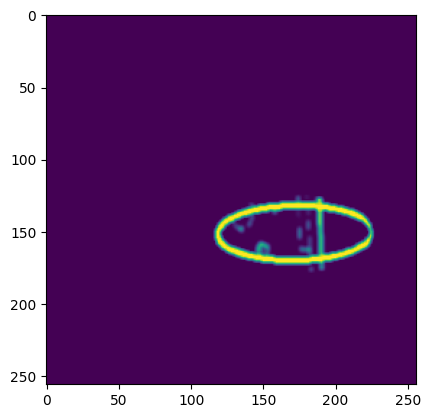

In [13]:
# from randomizedHoughEllipseDetection import FindEllipseRHT
import time
import cv2
import matplotlib.pyplot as plt
import numpy as np

path = "D:\\1LAB"
original_image_path = "../tmp/hehe5.png"
original_image = cv2.imread(original_image_path)  #"../tmp/v5_bacground.png"
original_image = cv2.blur(original_image, (5, 5))

from image_tuner import rgb_tune_from_params

original_image = rgb_tune_from_params(original_image, 216, 212, 204, 255, 255, 255)  # 128, 167, 196, 255, 255, 255)
original_image = cv2.resize(original_image, (256, 256), interpolation=cv2.INTER_LINEAR)
original_image = cv2.blur(original_image, (3, 3))
print(original_image)
# original_image = cv2.cvtColor(original_image,cv2.COLOR_RGB2GRAY)
# mask = cv2.imread(path + "\\1619_mask.png", 0)
mask_binary = np.zeros(original_image.shape, dtype=bool)
mask_binary[original_image == 255] = False
mask_binary[original_image != 255] = True

time1 = time.time()
test = FindEllipseRHT(original_image, mask_binary)
# plt.figure()
# plt.imshow(original_image)
# plt.show()
test.max_iter = 200000
test.score_threshold = 10
data = test.run(plot_mode=False, debug_mode=False)

# data = data.tolist()
# data = sorted(data, key=lambda item: -item[5])
best_id = 0
best_metric = -1e9
# for i in range(len(data)):
#     tmp_metric = (1e6* data[i][5]+metric_by_points(data[i][0], data[i][1], data[i][2], data[i][3], data[i][4], original_image) /math.sqrt(data[i][2]*data[i][3]))
#     if tmp_metric > best_metric:
#         best_metric = tmp_metric
#         best_id = i
data[0] = data[best_id]
best = data[0][0]
for i in range(len(best)):
    best[i] = int(best[i])
delta = 0.2
# original_image*=0
# original_image+=255
# original_image = cv2.ellipse(original_image, best[0:2], (int(best[2] * (1 - delta)), int(best[3] * (1 - delta))),
#                              data[0][0][4], 0, 360, (0, 0, 0), -1)
# mask = cv2.ellipse(np.zeros_like(original_image), best[0:2], (int(best[2] * (1 + delta)), int(best[3] * (1 + delta))),
#                    data[0][0][4], 0, 360, (255, 255, 255), -1)
original_image = cv2.ellipse(original_image,list(map(lambda xx: int(xx),data[0][0][0:2])),list(map(lambda xx: int(xx),data[0][0][2:4])),data[0][0][4],0,360,(255,255,255),3)
original_image = np.bitwise_and(original_image, mask)
original_image = cv2.blur(original_image, (3, 3))
time2 = time.time()

test = FindEllipseRHT(original_image, mask_binary)
# cv2.imshow("hehe",mask)
# cv2.waitKey(0)
plt.figure()
plt.imshow(original_image)
plt.show()
test.max_iter = 200000
data = test.run(plot_mode=False, debug_mode=False)
# print("time consume: ", time2 - time1)
# print(data)
# angle = 0.5
# A = 2
# C= 3
# AXIS_MAT = np.array([[np.sin(angle)**2 , np.cos(angle)**2], [np.cos(angle)**2, np.sin(angle)**2]])
# AXIS_MAT_ANS = np.array([A, C])
# np.linalg.solve(AXIS_MAT,AXIS_MAT_ANS  

In [29]:
# cv2.imshow("hehe5",cv2.imread("../tmp/hehe5.png"))
# cv2.waitKey(0)
# cv2.destroyAllWindows()

1
[[[ 71  74  76]
  [ 71  74  76]
  [ 71  74  76]
  ...
  [ 89  91  87]
  [ 90  91  87]
  [ 90  90  88]]

 [[ 71  74  76]
  [ 71  74  76]
  [ 71  74  76]
  ...
  [ 89  91  87]
  [ 90  91  87]
  [ 90  90  88]]

 [[143 149 153]
  [143 149 153]
  [142 148 152]
  ...
  [178 180 173]
  [178 180 174]
  [179 180 175]]

 ...

 [[252 251 253]
  [252 251 253]
  [253 252 254]
  ...
  [242 245 245]
  [242 245 245]
  [242 245 245]]

 [[252 251 253]
  [252 251 253]
  [252 251 253]
  ...
  [242 245 245]
  [242 245 245]
  [242 245 245]]

 [[252 251 253]
  [252 251 253]
  [252 251 253]
  ...
  [242 245 245]
  [242 245 245]
  [242 245 245]]] hehe [[ 71  74  76]
 [ 71  74  76]
 [ 71  74  76]
 ...
 [242 245 245]
 [242 245 245]
 [242 245 245]] <class 'numpy.ndarray'> hehe [[110, 154, 98], [228, 232, 225], [182, 189, 180], [86, 125, 76], [140, 149, 138], [205, 212, 205], [160, 168, 161], [107, 77, 47], [118, 120, 109], [58, 66, 47], [249, 250, 249]]
[[180 180 180 ...  60  60  60]
 [180 180 180 ...  60  60  

C:\Users\shishkin_i\AppData\Local\Temp\ipykernel_13600\2609612981.py:295: RuntimeWarning: divide by zero encountered in scalar divide
  slope = (m1[1] - t12[1]) / (m1[0] - t12[0])  #todo devision by zero
C:\Users\shishkin_i\AppData\Local\Temp\ipykernel_13600\2609612981.py:296: RuntimeWarning: divide by zero encountered in scalar divide
  intercept = (m1[0] * t12[1] - t12[0] * m1[1]) / (m1[0] - t12[0])
C:\Users\shishkin_i\AppData\Local\Temp\ipykernel_13600\2609612981.py:338: RuntimeWarning: invalid value encountered in sqrt
  minor = 1 / np.sqrt(min(X, Y))


Singular matrix
Singular matrix


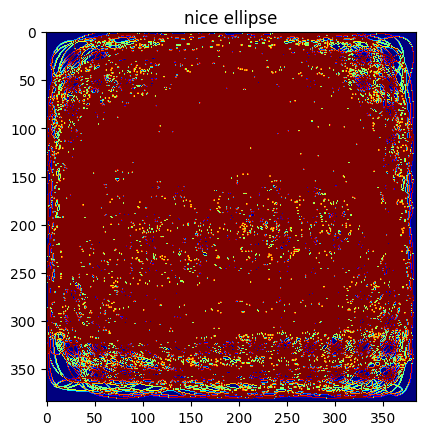

[[116 116 116 ...  56  47  47]
 [116 116 116 ...  55  47  47]
 [108 108 108 ...  52  46  46]
 ...
 [200 200 200 ... 200 200 200]
 [200 200 200 ... 200 200 200]
 [200 200 200 ... 200 200 200]]


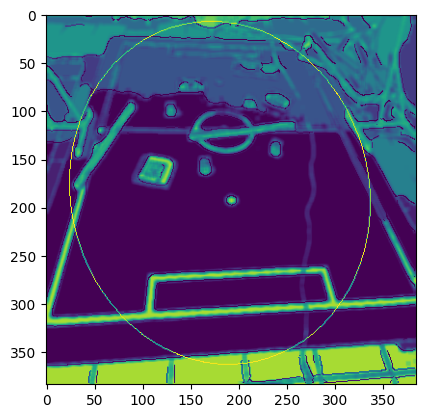

In [92]:
input_video_path = "F:\\Videos\\2024-11-18 17-53-16.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"  #"F:\\Videos\\2024-11-18 17-49-57.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"

cap = cv2.VideoCapture(input_video_path)

output_video_path = '..\\tmp\\4_right_up_processed_last4.mp4'
from utils.cut_image import get_cut_frame_from_frame

fps = cap.get(cv2.CAP_PROP_FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
ellipse_list_video = list()

fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Кодек для сохранения видео

# Создаем объект для записи нового видео
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))
cntr = 0
while True:
    cntr += 1
    print(cntr)
    ret, image = cap.read()
    if not ret:
        break
    to_scale = 5
    image = get_cut_frame_from_frame(image, 2)
    image = cv2.rotate(image, cv2.ROTATE_180)
    image = cv2.blur(image, (2, 2))
    # image = cv2.blur(image, (2, 2))
    image_t = cluster_and_recolor(image, 11)
    print(image_t, type(image_t), type(image_t[0][0]), image_t.shape)
    # image_t = rgb_tune_from_params(image, 119, 151, 90, 146, 164, 134)#217, 213, 210, 237, 230,
    #223)  #201,199,198, 255, 255, 255)#253, 251, 250, 255, 255, 255)  #216, 212, 204, 255, 255, 255)
    # print(image_t,type(image_t),type(image_t[0][0]),image_t.shape)
    image_t = cv2.resize(image_t, (frame_width // to_scale, frame_width // to_scale), interpolation=cv2.INTER_LINEAR)
    image_t = cv2.blur(image_t, (5, 5))
    # cv2.imwrite("../tmp/hehe4.png", image)
    # break
    print(image_t.shape)
    test = FindEllipseRHT(image_t)
    test.max_iter = 4000
    data = test.run(plot_mode=True, debug_mode=False)
    # data[0][1]=data[0][1]*to_scale
    # data[0][2]=data[0][2]*to_scale
    # data[0][3]=data[0][3]*to_scale
    # data[0][0]=data[0][0]*to_scale
    ellipse_list_video.append(data[0])
    # for i in range(len(data[0])):
    #     ellipse_list_video[-1][i] = float(ellipse_list_video[-1][i])
    ellipse_list_video[-1] = list(map(int, ellipse_list_video[-1]))
    image_t = cv2.resize(image, (frame_width // to_scale, frame_width // to_scale), interpolation=cv2.INTER_LINEAR)
    clustered_frame = cv2.ellipse(image_t, ellipse_list_video[-1][0:2], ellipse_list_video[-1][2:4],
                                  ellipse_list_video[-1][4], 0, 360, color=(100, 100, 100), thickness=5)
    # cv2.imshow("hehe",clustered_frame)
    # cv2.waitKey()
    clustered_frame = cv2.resize(clustered_frame, (frame_width, frame_height), interpolation=cv2.INTER_LINEAR)

    out.write(clustered_frame)
    if cntr > 0:
        break
cap.release()
out.release()
cv2.destroyAllWindows()

In [105]:
cap.release()
out.release()
cv2.destroyAllWindows()
print(ellipse_list_video)
for i in range(len(ellipse_list_video) - 10):
    for j in range(len(ellipse_list_video[i]) - 3):
        print(float(ellipse_list_video[i][j] - ellipse_list_video[i + 5][j]))

[[901, 1227, 224, 184, 1, 3], [907, 1210, 241, 177, 1, 2], [905, 1214, 252, 197, 1, 4], [898, 1233, 234, 198, 1, 2], [776, 742, 731, 305, 1, 2], [890, 1210, 249, 186, 1, 3], [916, 1218, 257, 200, -1, 4], [914, 1201, 250, 184, 1, 5], [1016, 824, 704, 527, 0, 2], [1034, 966, 391, 80, 0, 2], [915, 1183, 244, 180, 1, 2], [921, 1197, 243, 176, 1, 3], [989, 736, 717, 303, -1, 3], [902, 1213, 252, 175, 1, 3], [919, 1202, 240, 196, 1, 4], [882, 1198, 249, 190, -1, 2], [839, 750, 730, 339, 1, 2], [892, 1200, 247, 177, -1, 5], [1115, 1075, 638, 177, 0, 1], [874, 1250, 270, 177, 0, 3], [903, 1222, 246, 183, -1, 3], [900, 1205, 254, 177, 1, 5], [879, 1207, 224, 171, -1, 3], [799, 751, 739, 236, 1, 2], [920, 1202, 247, 189, 1, 4], [892, 1222, 228, 167, -1, 3], [917, 1201, 241, 182, 1, 4], [972, 731, 718, 258, -1, 2], [1107, 1126, 438, 282, 0, 2], [896, 1210, 254, 196, 1, 5], [910, 1195, 242, 161, 1, 2], [897, 1221, 222, 159, 1, 3], [924, 1229, 235, 171, 1, 2], [868, 1197, 245, 179, 1, 2], [895, 119

In [35]:
from image_tuner import tune_test

tune_test("../tmp/hehe4.png")  #27,32,32,167,207,162
from image_tuner import rgb_tune_test

# rgb_tune_test("../tmp/hehe4.png")
# from image_tuner import rgb_tune_from_params
# 
# original_image = rgb_tune_from_params(original_image, 128, 167, 196, 255, 255, 255)
# print("hf")
# plt.imshow(original_image)

68 27 89 105 77 255


gradient decent with best ellipse possible

In [ ]:
import math
import torch
import cv2

import matplotlib.pyplot as plt

# img = cv2.imread('../tmp/v5_bacground.png', cv2.IMREAD_COLOR)  # road.png is the filename
# generated = torch.randn(5)*100
# print(generated)
# img = img*0+100
# img = cv2.ellipse(img,(int(generated[0]+100),int(generated[1]+100)),(abs(int(generated[2])),abs(int(generated[3]))),float(generated[4]),0,360,color=(0,0,0),thickness=10)
# ksize = (60,60)
# for i in range(10):
#     img = cv2.blur(img,ksize=ksize)
# Convert the image to grayscale
# img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# image_torch = torch.from_numpy(img)
# print(image_torch)
# plt.imshow(img)
# cv2.imshow("eheh",img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# center = torch.tensor([0.,0.], requires_grad=True)
# ax = torch.tensor(0., requires_grad=True)
# bx = torch.tensor(0., requires_grad=True)
# width = torch.tensor(0., requires_grad=True)
# params = torch.randn((5), requires_grad=True)


In [ ]:

# loss_BGD = []

In [54]:
import torch

In [ ]:
# x_0 = torch.randn((1), requires_grad=True)
# y_0 = torch.randn((1), requires_grad=True)
# angle = torch.randn((1), requires_grad=True)
# a = torch.randn((1), requires_grad=True)
# b = torch.randn((1), requires_grad=True)

In [62]:
def points_on_ellipse(x_0, y_0, a, b, angle, n: int = 10) -> list[(torch.tensor, torch.tensor)]:
    points = list()
    for i in range(n):
        point = (math.cos(i / math.pi / 2), math.sin(i / math.pi / 2))
        point = (point[0] * a, point[1] * b)
        point = (point[0] * math.cos(angle) + point[1] * math.sin(angle),
                 -point[0] * math.sin(angle) + point[1] * math.cos(angle))
        point = (point[0] + x_0, point[1] + y_0)
        points.append(point)
    return points


def points_on_line(from_x, from_y, to_x, to_y):
    ans = list()
    if math.fabs(from_x - to_x) > math.fabs(from_y - to_y):
        step_x = (to_x - from_x) / (to_y - from_y)
        for i in range(int(from_y), int(to_y) + 1, int((to_y - from_y) / math.fabs(to_y - from_y))):
            ans.append((int(step_x * i + from_x), int(i + from_y)))
    else:
        step_y = (to_y - from_y) / (to_x - from_x)
        for i in range(int(from_x), int(to_x) + 1, int((to_x - from_x) / math.fabs(to_x - from_x))):
            ans.append((int(i + from_x), int(step_y * i + from_y)))
    return ans


def points_on_line_v2(from_x, from_y, to_x, to_y, n_steps=None):
    if n_steps is None:
        return points_on_line(from_x, from_y, to_x, to_y)
    ans = list()
    step_x = (to_x - from_x) / n_steps
    step_y = (to_y - from_y) / n_steps
    for i in range(n_steps):
        ans.append((round(from_x + step_x * i), round(from_y + step_y * i)))
    return ans


def metric_by_points(x_0, y_0, a, b, angle, data, n: int = 20) -> torch.tensor:
    points = points_on_ellipse(x_0, y_0, a, b, angle, n)
    ans = torch.zeros(1)
    for i in range(n):
        for j in points_on_line_v2(points[i][0], points[i][1], points[(i + 1) % n][0], points[(i + 1) % n][1],
                                   1 + round(max(abs(points[i][0] - points[(i + 1) % n][0]),
                                                 abs(points[i][0] - points[(i + 1) % n][0])))):
            if 0 <= j[0] < data.shape[0] and 0 <= j[1] < data.shape[1]:
                ans += data[j[0]][j[1]]
                if data[j[0]][j[1]] == 0:
                    ans -= 1000
    return ans

In [ ]:
import copy


class TinyModel(torch.nn.Module):
    def __init__(self, x_0, y_0, a, b, angle):
        super(TinyModel, self).__init__()

        self.x_0 = torch.nn.Parameter(torch.tensor(x_0, requires_grad=True))
        self.y_0 = torch.nn.Parameter(torch.tensor(y_0, requires_grad=True))
        self.angle = torch.nn.Parameter(torch.tensor(angle, requires_grad=True))
        self.a = torch.nn.Parameter(torch.tensor(a, requires_grad=True))
        self.b = torch.nn.Parameter(torch.tensor(b, requires_grad=True))
        self.loss_BGD = []

    def convert(self, px_0, py_0, pangle, pa, pb):  #ax**2+bx+cy**2+dy+exy+f = 0
        # if abs(pa)<eps:
        #     pa += eps * torch.sign(pa)
        # if abs(pb)<eps:
        #     pb += eps * torch.sign(pb)
        s_ang = torch.sin(pangle)
        c_ang = torch.cos(pangle)
        return torch.stack(
            [c_ang ** 2 / pa ** 2 + s_ang ** 2 / pb ** 2, 2 * (c_ang * px_0 / pa ** 2 + s_ang * py_0 / pb ** 2),
             s_ang ** 2 / pa ** 2 + c_ang ** 2 / pb ** 2, 2 * (-s_ang * px_0 / pa ** 2 + c_ang * py_0 / pb ** 2),
             2 * (c_ang * s_ang) * (-1 / pa ** 2 + 1 / pb ** 2),
             (px_0 / pa) ** 2 + (py_0 / pb) ** 2])  # maybe -1 to the last one

    # params = 0
    def forward(self, x):
        # global params
        params = self.convert(self.x_0, self.y_0, self.angle, self.a, self.b)
        return torch.einsum('ij,j->i', x, params)


class Model:

    def __init__(self, x_0, y_0, a, b, angle):
        self.model = TinyModel(x_0, y_0, a, b, angle)
        self.eps = 1e-5
        self.loss_BGD = []
        self.metric_BGD = []
        self.best_loss = 1e30
        self.best_metric = 1e-30

    # 
    def loss_c(self, val, X_v):
        perimeter = math.pi * torch.sqrt((self.model.a ** 2 + self.model.b ** 2) * 2)
        # val =(val + 1 / (
        #         self.eps + val))-2

        return torch.sqrt(torch.sum(
            val * X_v)) + perimeter + self.model.angle ** 2 * 0.3  # +self.model.a**2+self.model.b**2+self.model.angle**2 

    # def loss_c(val):
    #     return torch.sum(val**2)**(0.2)#+torch.sum(params**3)

    # xs = torch.randn((5, 5))
    # print(loss_c(forward(xs)))
    def solve(self, img, debug=False, n_steps=1000, loss_fn=None, metric_fn=None):
        if loss_fn is not None:
            self.loss = loss_fn
        else:
            def tmp(a, b, c):
                return self.loss_c(b, c)

            self.loss = tmp
        self.optim = torch.optim.Adam(self.model.parameters(), lr=0.1)
        X_v = torch.from_numpy(cv2.cvtColor(img, cv2.COLOR_BayerGR2GRAY)).type(torch.float64)
        # print(X_v)
        X_1 = torch.stack([torch.ones((X_v.shape[0])) * size for size in range(0, X_v.shape[1])]).type(torch.float64)
        #X_1 -= X_v.shape[1]//2
        X_2 = torch.stack([torch.ones((X_v.shape[1])) * size for size in range(0, X_v.shape[0])]).type(torch.float64)
        #X_2 -= X_v.shape[0]//2
        X_2 = torch.transpose(X_2, 0, 1)
        if debug:
            print(X_1, X_2)
        # print(X_1.shape, X_2.shape)
        X_1 = torch.flatten(X_1)
        X_2 = torch.flatten(X_2)
        X_v = torch.flatten(X_v)
        X_v = X_v - torch.min(X_v)
        # X_v = torch.max(X_v) - X_v
        X = torch.stack([X_1 ** 2, X_1, X_2 ** 2, X_2, X_1 * X_2, torch.ones_like(X_1)])
        if debug:
            print(X)
        X = torch.transpose(X, 0, 1)
        loss = self.loss(self, self.model.forward(X), X_v)
        self.best_loss = 1e20
        self.best_model = copy.deepcopy(self.model)
        for i in range(n_steps):
            # making predictions with forward pass
            Y = self.model.forward(X)
            # calculating the loss between original and predicted data points
            loss = self.loss(self, Y, X_v)
            if metric_fn is not None:
                self.metric_BGD.append(
                    metric_fn(float(self.model.x_0), float(self.model.y_0), float(self.model.a), float(self.model.b),
                              float(self.model.angle), img))
            if debug:
                print(torch.min(Y))
                if torch.min(Y) < -0.1:
                    print(
                        "bbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbb")
            # storing the calculated loss in a list
            self.loss_BGD.append(loss.item())
            # backward pass for computing the gradients of the loss w.r.t to learnable parameters
            loss.backward()
            self.optim.step()
            self.optim.zero_grad()
            if i % 10 == 0 and debug:
                print(loss, " is loss")
                print(float(self.model.x_0), float(self.model.y_0), float(self.model.angle), float(self.model.a),
                      float(self.model.b), " is params")
            if loss < self.best_loss and metric_fn is None:
                self.best_loss = float(loss)
                self.best_model = copy.deepcopy(self.model)
            elif metric_fn is not None and self.metric_BGD[-1] > self.best_metric:
                self.best_model = copy.deepcopy(self.model)
                self.best_metric = self.metric_BGD[-1]
        # self.model = self.best_model
        return self.best_loss



In [ ]:

val = 1
val = float((torch.randn((1)))) * 0.3 + 0.5

In [ ]:
best_metric = 1e9
best_enum = 0
print(val)
for enum in range(int(len(data) * 0.9 * val), int(len(data) * 0.9 * val) + 10):
    if enum >= len(data):
        break
    i = data[enum]
    md = Model(i[0], i[1], i[2], i[3], i[4])
    metric = float(md.solve(original_image, n_steps=100))
    print(metric)
    if metric < best_metric:
        best_metric = metric
        best_enum = enum
# best_enum = 0
print(best_enum)
best_md = Model(data[best_enum][0], data[best_enum][1], data[best_enum][2], data[best_enum][3], data[best_enum][4])
best_md.solve(original_image, n_steps=1000, debug=False, metric_fn=metric_by_points)

In [ ]:

from functools import partial

# ax = plt.plot(loss_BGD, label="Batch Gradient Descent")
img = cv2.imread(original_image_path)
# img = original_image
fig, ax = plt.subplots()
# best_md.model = best_md.best_model
model = best_md.best_model
ax.plot(best_md.loss_BGD)
plt.plot(best_md.metric_BGD)
print(best_md.metric_BGD)
print(model.x_0, model.y_0, model.a, model.b, model.angle)
# plt.xlabel('Epoch')
# plt.ylabel('Cost/Total loss')
# plt.legend()

# ax.set_yscale('function', functions=(partial(np.power, 10.0), np.log10))
# ax.set(xlim=(1,2000),ylim=(10,100))

# ax.set_yticks([1, 3, 3.5, 3.75, 4.0])
plt.show()

image = cv2.ellipse(img, (int(model.x_0), int(model.y_0)),
                    (abs(int(model.a)), abs(int(model.b))), float(model.angle), 0, 360,
                    color=(0, 0, 0))
# image = cv2.ellipse(img,(int(data[best_enum][0]),int(data[best_enum][1])),(abs(int(data[best_enum][2])),abs(int(data[best_enum][3]))),float(data[best_enum][4]),0,360,color=(0,0,0))
# print(image.shape)
print(type(image))
# image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(image)

так как модель расходится необходимо выбрать лосс, на котором все будет сходится

In [ ]:
losses = list()
codes = list()
cntr = 0
for perim in "+/":
    for val_n1 in ("#", ""):
        for val_n2 in ("#", ""):
            lossfn = \
                f"""
def loss{cntr}(self, val, X_v):
    perimeter = math.pi * torch.sqrt((self.model.a ** 2 + self.model.b ** 2) * 2)
    {val_n1}val = val + 1/(self.eps+val) {val_n2} -2 +self.eps
    return torch.sqrt(torch.sum(val * X_v))  {perim} perimeter
losses.append(loss{cntr})
""";
            cntr += 1;
            exec(lossfn);
            codes.append(lossfn)
print(losses)

In [ ]:
best_metric_max_value = -1e30
best_metric_id = 0
for i in range(len(losses)):
    best_md = Model(data[best_enum][0], data[best_enum][1], data[best_enum][2], data[best_enum][3], data[best_enum][4])
    best_md.solve(original_image, n_steps=1000, debug=False, metric_fn=metric_by_points, loss_fn=losses[i])
    current_best = -1e30
    current_best_id = 0
    for j in best_md.metric_BGD:
        if current_best < j:
            current_best = j
    if best_metric_max_value < current_best:
        best_metric_max_value = current_best
        best_metric_id = current_best_id
    print(best_metric_max_value, current_best, "current best")
print(codes[best_metric_id])

camera position recounting

In [ ]:

import math


def ellipse_tangent_points(ex, ey, ea, eb, eang, a, b):
    if a == 0 and b == 0:
        return ()

    y_0 = b * ea / math.sqrt(eb ** 4 + ea ** 4)
    x_0 = a * ea / math.sqrt(eb ** 4 + ea ** 4)
    x_0, y_0 = math.cos(eang) * x_0 + math.sin(eang) * y_0, -math.sin(eang) * x_0 + math.cos(eang) * y_0
    return ((x_0 + ex, y_0 + ey), (-x_0 + ex, -y_0 + ey))  #todo: fix: line should also rotate in the beginning


def recount_camera_position(ex, ey, ea, eb, eang):
    #constants
    point_dist = None
    pixel_distance = None
    real_radius = None

    axis_direction = (math.sin(eang) * eb, math.cos(eang) * eb)

    #to compute
    distance_to_camera = None
    height_of_camera = None
    horizontal_move = None

    #todo: assuming this, which is not always true
    vertical_angle_of_camera = 0
    horizontal_angle_of_camera = 0
    rotation_of_camera = 0

    return (distance_to_camera, height_of_camera, horizontal_move, vertical_angle_of_camera, horizontal_angle_of_camera,
            rotation_of_camera)






In [ ]:
# AI -generated
# TODO: test this cell

import cv2
import numpy as np


def detect_central_circle(image_path):
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print("Error: Image not found")
        return
    height, width = image.shape[:2]

    # Convert to HSV color space for better color segmentation
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define range for white color (field markings)
    lower_white = np.array([0, 0, 200])
    upper_white = np.array([180, 30, 255])
    mask = cv2.inRange(hsv, lower_white, upper_white)

    # Apply morphological operations to reduce noise
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # Find edges using Canny detector
    edges = cv2.Canny(mask, 50, 150)

    # Find contours in the edge map
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    best_ellipse = None
    max_area = 0

    for contour in contours:
        # Skip small contours
        if len(contour) < 5:
            continue

        # Fit ellipse to the contour
        ellipse = cv2.fitEllipse(contour)
        (center, axes, angle) = ellipse
        major_axis = max(axes)
        minor_axis = min(axes)

        # Calculate ellipse area and aspect ratio
        area = np.pi * (major_axis / 2) * (minor_axis / 2)
        aspect_ratio = major_axis / minor_axis if minor_axis != 0 else 0

        # Filter based on area, aspect ratio, and position
        if (area > 500 and
                0.5 < aspect_ratio < 3 and
                (width * 0.3 < center[0] < width * 0.7) and
                (height * 0.3 < center[1] < height * 0.7)):

            if area > max_area:
                max_area = area
                best_ellipse = ellipse

    # Draw the detected ellipse and its center
    if best_ellipse is not None:
        cv2.ellipse(image, best_ellipse, (0, 255, 0), 2)
        center = (int(best_ellipse[0][0]), int(best_ellipse[0][1]))
        cv2.circle(image, center, 5, (0, 0, 255), -1)

    # Display the result
    cv2.imshow("hehe", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

